## Plot viz


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from R_utilities import mappatura_dataset,mappatura_modelli
# Definisci la cartella contenente i file CSV


In [6]:
cartella_output = '../output_def/'  # Sostituisci con il percorso corretto

1240 1965
21895 39461
19879 39461
189 627
304 627
132 4554
1206 1965
1639 1965
141 4554
171 627
31578 39461
76 4554
18895 39461
604 4554
1214 1965
119 627
     model_name dataset_name  percentuale
0  Llama-3.2-1B         cade    63.104326
1  Llama-3.2-1B       corpus    55.485163
2    Qwen2.5-7B       corpus    50.376321
3  Llama-3.1-8B    attitudes    30.143541
4    Qwen2.5-7B    attitudes    48.484848


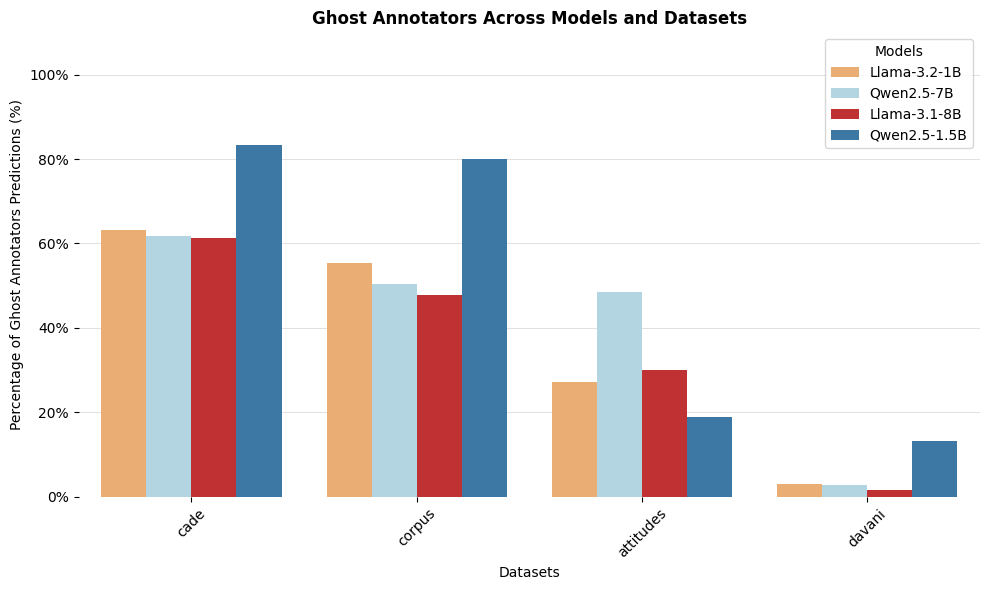

In [45]:
# Funzione per calcolare la percentuale di predizioni del modello mai selezionate dagli annotatori
def calcola_percentuale_predizioni(file_csv):
    # Leggi il file CSV
    df = pd.read_csv(file_csv)

    # Raggruppa i dati per comment_id e annotator_id
    annotazioni_umanes = df[['comment_id', 'label']].drop_duplicates()

    # Unisce con le predizioni del modello per calcolare la percentuale
    predizioni_modello = df[['comment_id', 'label_model']].drop_duplicates()

    # Raggruppiamo le etichette degli annotatori per ogni comment_id
    annotazioni_per_comment_id = annotazioni_umanes.groupby('comment_id')['label'].apply(set).reset_index()

    # Aggiungiamo le etichette degli annotatori al DataFrame delle predizioni
    df_completo = pd.merge(predizioni_modello, annotazioni_per_comment_id, on='comment_id', how='left')

    count=0
    for index, row in df_completo.iterrows():

        if row['label_model'] not in row['label']:
            #print(row)
            count+=1
    
    print(count,df['comment_id'].nunique())

    # Calcola la percentuale di predizioni "mai selezionate" rispetto al totale delle predizioni per ogni modello e dataset
    model_name, dataset_name = file_csv.split('_')[3].split('Instruct')[0][0:-1], file_csv.split('_')[-1].split(".")[0]
    
    if count==0:
        percentuale=0
    else:
        percentuale = count/df['comment_id'].nunique() * 100
    return model_name, dataset_name, percentuale

# Lista dei file CSV nella cartella di output
file_csvs = [f for f in os.listdir(cartella_output) if f.startswith('step_1_') and f.endswith('.csv')]

# Crea un DataFrame vuoto per contenere i risultati
dati_per_grafico = []

# Calcola la percentuale per ogni file CSV
for file_csv in file_csvs:
    model_name, dataset_name, percentuale = calcola_percentuale_predizioni(os.path.join(cartella_output, file_csv))
    dati_per_grafico.append([model_name, dataset_name, percentuale])

# Crea un DataFrame con i risultati
df_risultati = pd.DataFrame(dati_per_grafico, columns=['model_name', 'dataset_name', 'percentuale'])

print(df_risultati.head())


# Creazione del grafico
plt.figure(figsize=(10, 6))

# Grafico a barre raggruppate con seaborn
modelli_ordinati = ['Llama-3.2-1B',  'Qwen2.5-1.5B','Llama-3.1-8B','Qwen2.5-7B']  # Sostituisci con i tuoi nomi di modello


sns.barplot(x='dataset_name', y='percentuale', hue='model_name', data=df_risultati,  hue_order=df_risultati['model_name'].unique(), palette=['#fdae61','#abd9e9','#d7191c','#2c7bb6'], zorder=3)


plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0f}%'))
plt.ylim(0, 110)
plt.legend(title="Models")
plt.grid(axis='y', color='lightgray', linestyle='-', linewidth=0.5, zorder=0)  # Griglia orizzontale, grigia chiara
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
# Aggiungi titoli e etichette
plt.title('Ghost Annotators Across Models and Datasets', fontweight='bold')
plt.xlabel('Datasets')
plt.ylabel('Percentage of Ghost Annotators Predictions (%)')
plt.xticks(rotation=45)
plt.tight_layout()

# Mostra il grafico

#Save in pdf
if not os.path.exists('figures'):
    os.makedirs('figures')
plt.savefig('figures/ghost_annotators_across_models_datasets.pdf', format='pdf', bbox_inches='tight')
plt.show()
